---
title: Shallow Neural Networks
---

::: {.callout-tip}
## Slides
[Slides](https://docs.google.com/presentation/d/16tA4OMIaZcd1K1m4KHBcf5CYnqiCW85l62AnuUBzmfs/edit)
::: 



## Neural Network Example 


$$
\begin{aligned}
y
&= f[x,\boldsymbol{\phi}] \\
&= \phi_0
 + \phi_1 a[\theta_{10}+\theta_{11}x]
 + \phi_2 a[\theta_{20}+\theta_{21}x]
 + \phi_3 a[\theta_{30}+\theta_{31}x].
\end{aligned}
\tag{1}
$$


<img src="assets/Chap03/ShallowReLU.svg" style="filter: invert(1);" width="50%" align="right">

Rectified linear unit (ReLU).
This activation function returns zero if
the input is less than zero and returns
the input unchanged otherwise. In other
words, it clips negative values to zero.
Note that there are many other possi-
ble choices for the activation function
(see figure 3.13), but the ReLU is the
most commonly used and the easiest to
understand.

$$
a[z]
=
\operatorname{ReLU}(z)
=
\begin{cases}
0, & z < 0, \\
z, & z \geq 0.
\end{cases}
\tag{1}
$$



In [ ]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):

  activation = []
  for z in preactivation: 
    if z < 0: 
      activation.append(0)
    else:
      activation.append(x)
      
  # One line equivalent
  # activation = preactivation.clip(0, None)

  return activation

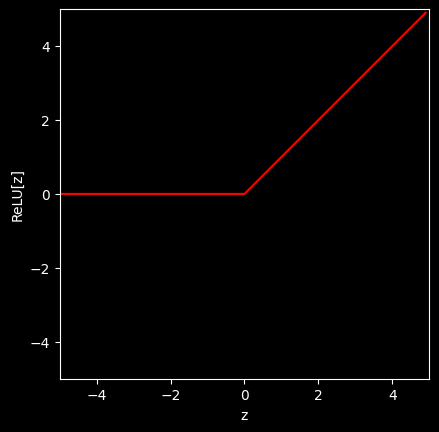

In [25]:
# Make an array of inputs
z = np.arange(-5,5,0.1)
RelU_z = ReLU(z)

# Plot the ReLU function
fig, ax = plt.subplots()
ax.plot(z,RelU_z,'r-')
ax.set_xlim([-5,5]);ax.set_ylim([-5,5])
ax.set_xlabel('z'); ax.set_ylabel('ReLU[z]')
ax.set_aspect('equal')
plt.show()



<img src="assets/Chap03/ShallowFunctions.svg" style="filter: invert(1);" width="100%">

Family of functions defined by equation 3.1. a–c) Functions for three different choices of the ten parameters ϕ. In each case, the input/output relation is piecewise linear. However, the positions of the joints, the slopes of the linear
regions between them, and the overall height vary.

### Neural Network intuition 

$$
\begin{aligned}
h_1 &= a[\theta_{10}+\theta_{11}x], \\
h_2 &= a[\theta_{20}+\theta_{21}x], \\
h_3 &= a[\theta_{30}+\theta_{31}x].
\end{aligned}
\tag{1}
$$

$$
y
=
\phi_0+\phi_1h_1+\phi_2h_2+\phi_3h_3.
\tag{2}
$$

<img src="assets/Chap03/ShallowBuildUp.svg" style="filter: invert(1);" width="100%">

Computation for function in figure 3.2a. a–c) The input x is passed through three linear functions, each with a different y-intercept θ•0 and slope θ•1. d–f) Each line is passed through the ReLU activation function, which clips negative
values to zero. g–i) The three clipped lines are then weighted (scaled) by ϕ1, ϕ2, and ϕ3, respectively. j) Finally, the clipped and weighted functions are summed, and an offset ϕ0 that controls the height is added. Each of the four linear regions corresponds to a different activation pattern in the hidden units.
In the shaded region, h2 is inactive (clipped), but h1 and h3 are both active.
(Interactive figure)

In [19]:
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # TODO Replace the code below to compute the three initial lines
  # from the theta parameters (i.e. implement equations at bottom of figure 3.3a-c).  These are the preactivations
  pre_1 = np.zeros_like(x)
  pre_2 = np.zeros_like(x)
  pre_3 = np.zeros_like(x)

  # Pass these through the ReLU function to compute the activations as in
  # figure 3.3 d-f
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  # TODO Replace the code below to weight the activations using phi1, phi2 and phi3
  # To create the equivalent of figure 3.3 g-i
  w_act_1 = np.zeros_like(x)
  w_act_2 = np.zeros_like(x)
  w_act_3 = np.zeros_like(x)

  # TODO Replace the code below to combining the weighted activations and add
  # phi_0 to create the output as in figure 3.3 j
  y = np.zeros_like(x)

  # Return everything we have calculated
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [20]:
# Plot the shallow neural network.  We'll assume input in is range [0,1] and output [-1,1]
# If the plot_all flag is set to true, then we'll plot all the intermediate stages as in Figure 3.3
def plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False, x_data=None, y_data=None):

  # Plot intermediate plots if flag set
  if plot_all:
    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,pre_1,'r-'); ax[0,0].set_ylabel('Preactivation')
    ax[0,1].plot(x,pre_2,'b-'); ax[0,1].set_ylabel('Preactivation')
    ax[0,2].plot(x,pre_3,'g-'); ax[0,2].set_ylabel('Preactivation')
    ax[1,0].plot(x,act_1,'r-'); ax[1,0].set_ylabel('Activation')
    ax[1,1].plot(x,act_2,'b-'); ax[1,1].set_ylabel('Activation')
    ax[1,2].plot(x,act_3,'g-'); ax[1,2].set_ylabel('Activation')
    ax[2,0].plot(x,w_act_1,'r-'); ax[2,0].set_ylabel('Weighted Act')
    ax[2,1].plot(x,w_act_2,'b-'); ax[2,1].set_ylabel('Weighted Act')
    ax[2,2].plot(x,w_act_3,'g-'); ax[2,2].set_ylabel('Weighted Act')

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel('Input, ');
    plt.show()

  fig, ax = plt.subplots()
  ax.plot(x,y)
  ax.set_xlabel('Input, '); ax.set_ylabel('Output, ')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if x_data is not None:
    ax.plot(x_data, y_data, 'mo')
    for i in range(len(x_data)):
      ax.plot(x_data[i], y_data[i],)
  plt.show()

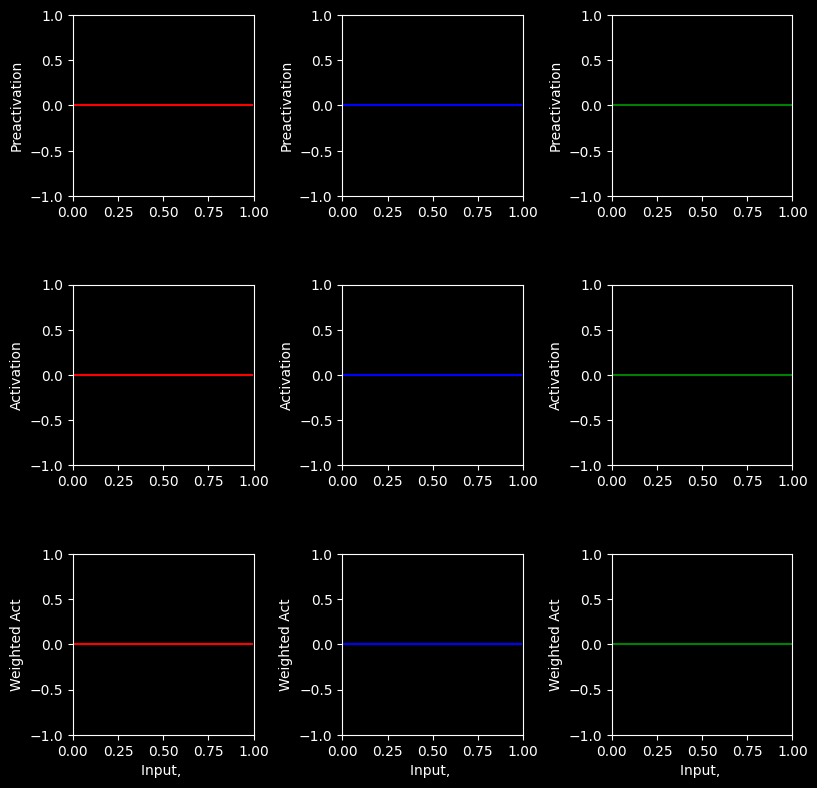

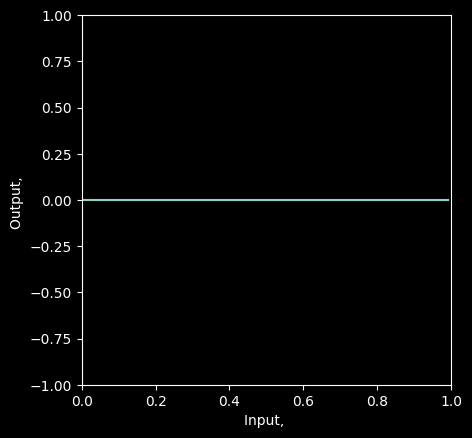

In [21]:
# Now lets define some parameters and run the neural network
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

In [ ]:

# Least squares function
def least_squares_loss(y_train, y_predict):
  # TODO Replace the line below to compute the sum of squared
  # differences between the real values of y and the predicted values from the model f[x_i,phi]
  # (see figure 2.2 of the book)
  # you will need to use the function np.sum
  loss = 0

  return loss

In [ ]:
# Now lets define some parameters, run the neural network, and compute the loss
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
x = np.arange(0,1,0.01)

x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.15934537,0.18195445,0.451270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.40716968,-0.08131792,0.41187806,0.36943738,0.3994327,\
                    0.019062570,0.35820410,0.452564960,-0.0183121,0.02957665,-0.24354444, \
                    0.148038840,0.26824970])

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True, x_data = x_train, y_data = y_train)

# Run the neural network on the training data
y_predict, *_ = shallow_1_1_3(x_train, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)

# Compute the least squares loss and print it out
loss = least_squares_loss(y_train,y_predict)
print('Your Loss = %3.3f, True value = 9.385'%(loss))

# TODO.  Manipulate the parameters (by hand!) to make the function
# fit the data better and try to reduce the loss to as small a number
# as possible.  The best that I could do was 0.181
# Tip... start by manipulating phi_0.
# It's not that easy, so don't spend too much time on this!



### Depicting neural networks 

<img src="assets/Chap03/ShallowNet.svg" style="filter: invert(1);" width="100%">

Depicting neural networks. a) The input x is on the left, the hidden units h1, h2, and h3 in the center, and the output y on the right. Computation
flows from left to right. The input is used to compute the hidden units, which are combined to create the output. Each of the ten arrows represents a parameter (intercepts in orange and slopes in black). Each parameter multiplies its source and adds the result to its target. For example, we multiply the parameter ϕ1
by source h1 and add it to y. We introduce additional nodes containing ones (orange circles) to incorporate the offsets into this scheme, so we multiply ϕ0 by one (with no effect) and add it to y. ReLU functions are applied at the hidden
units. b) More typically, the intercepts, ReLU functions, and parameter names are omitted; this simpler depiction represents the same network.

## Universal Approximation theorem 


\begin{eqnarray}
 h_{d} = \mbox{a}[\theta_{d0} + \theta_{d1}x], 
 \end{eqnarray}

\begin{eqnarray}\label{eq:snn_many_hidden}
 y = \phi_{0}+\sum_{d=1}^{D}\phi_{d}h_{d}.
 \end{eqnarray}